# Variational Autoencoder with 3D Latent Space — FIDS30

Same VAE recipe as `03_VAE_3D.ipynb` but trained on the **FIDS30** fruit dataset
(30 classes, RGB images resized to 64×64).

Key differences from the MNIST version:
- `x_dim = 3 × 64 × 64 = 12 288` (RGB instead of grayscale 28×28)
- Hidden dims scaled up to 2048 → 512
- `ImageFolder` dataset loader instead of `datasets.MNIST`
- 30 fruit classes instead of 10 digits

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import urllib.request
import zipfile
import shutil
import os
from pathlib import Path
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 0. Download & Prepare FIDS30

In [2]:
DATA_URL   = "https://data.vicos.si/datasets/FIDS30/FIDS30.zip"
ZIP_PATH   = Path("FIDS30.zip")
EXTRACT_DIR = Path("data")
SOURCE_BASE = EXTRACT_DIR / "FIDS30"
TARGET_BASE = Path("PrepData_FIDS30")

# --- download & extract ---
if not SOURCE_BASE.exists():
    if not ZIP_PATH.exists():
        print("Downloading FIDS30 dataset (~428 MB)...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
        print(f"Downloaded: {ZIP_PATH} ({ZIP_PATH.stat().st_size / 1e6:.1f} MB)")
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print(f"Extracted to {EXTRACT_DIR}/")
else:
    print("FIDS30 raw data already present.")

classes = sorted([d.name for d in SOURCE_BASE.iterdir() if d.is_dir()])
print(f"Found {len(classes)} classes: {classes}")

Downloaded: FIDS30.zip (428.4 MB)
Extracting...
Extracted to data/
Found 30 classes: ['acerolas', 'apples', 'apricots', 'avocados', 'bananas', 'blackberries', 'blueberries', 'cantaloupes', 'cherries', 'coconuts', 'figs', 'grapefruits', 'grapes', 'guava', 'kiwifruit', 'lemons', 'limes', 'mangos', 'olives', 'oranges', 'passionfruit', 'peaches', 'pears', 'pineapples', 'plums', 'pomegranates', 'raspberries', 'strawberries', 'tomatoes', 'watermelons']


In [3]:
# --- train / val / test split (stratified 60 / 20 / 20) ---
if not TARGET_BASE.exists():
    all_images, all_labels = [], []
    for cls_name in classes:
        cls_dir = SOURCE_BASE / cls_name
        imgs = [p for p in cls_dir.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]]
        all_images.extend(imgs)
        all_labels.extend([cls_name] * len(imgs))

    print(f"Total images: {len(all_images)} across {len(classes)} classes")

    train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
        all_images, all_labels, test_size=0.4, stratify=all_labels, random_state=42)
    val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
        temp_imgs, temp_lbls, test_size=0.5, stratify=temp_lbls, random_state=42)

    for split_name, (images, labels) in [("Training", (train_imgs, train_lbls)),
                                          ("Validation", (val_imgs, val_lbls)),
                                          ("Test", (test_imgs, test_lbls))]:
        for img_path, cls_name in zip(images, labels):
            dest_dir = TARGET_BASE / split_name / cls_name
            dest_dir.mkdir(parents=True, exist_ok=True)
            dest = dest_dir / img_path.name
            if not dest.exists():
                os.symlink(img_path.absolute(), dest)
        print(f"  {split_name}: {len(images)} images")
    print("Done! PrepData_FIDS30/ ready.")
else:
    print("PrepData_FIDS30/ already exists, skipping split.")

Total images: 971 across 30 classes
  Training: 582 images
  Validation: 194 images
  Test: 195 images
Done! PrepData_FIDS30/ ready.


In [4]:
IMG_SIZE = 64
x_dim    = 3 * IMG_SIZE * IMG_SIZE  # 12 288
bs       = 64

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),           # → [0, 1], compatible with BCE loss
])

train_dataset = datasets.ImageFolder(str(TARGET_BASE / "Training"),   transform=tfm)
test_dataset  = datasets.ImageFolder(str(TARGET_BASE / "Test"),        transform=tfm)

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False, num_workers=0)

class_names = train_dataset.classes
n_classes   = len(class_names)
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}, Classes: {n_classes}")
print(f"x_dim = {x_dim}")

Train: 582, Test: 195, Classes: 30
x_dim = 12288


## 1. Model

In [5]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super().__init__()
        # encoder
        self.fc1  = nn.Linear(x_dim,  h_dim1)
        self.fc2  = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)   # mu
        self.fc32 = nn.Linear(h_dim2, z_dim)   # log_var
        # decoder
        self.fc4  = nn.Linear(z_dim,  h_dim2)
        self.fc5  = nn.Linear(h_dim2, h_dim1)
        self.fc6  = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h)

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, x_dim))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var


vae = VAE(x_dim=x_dim, h_dim1=2048, h_dim2=512, z_dim=3).to(device)
print(vae)
n_params = sum(p.numel() for p in vae.parameters())
print(f"\nTotal parameters: {n_params:,}")

VAE(
  (fc1): Linear(in_features=12288, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=512, bias=True)
  (fc31): Linear(in_features=512, out_features=3, bias=True)
  (fc32): Linear(in_features=512, out_features=3, bias=True)
  (fc4): Linear(in_features=3, out_features=512, bias=True)
  (fc5): Linear(in_features=512, out_features=2048, bias=True)
  (fc6): Linear(in_features=2048, out_features=12288, bias=True)
)

Total parameters: 52,450,822


## 2. Loss and Optimizer

In [6]:
optimizer = optim.Adam(vae.parameters())

def loss_function(recon_x, x, mu, log_var):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, x_dim), reduction="sum")
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + KLD

## 3. Training

In [7]:
def train(epoch):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, log_var = vae(data)
        loss = loss_function(recon_batch, data, mu, log_var)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        if batch_idx % 5 == 0:
            print("Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.2f}".format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item() / len(data)))
    avg = train_loss / len(train_loader.dataset)
    print(f"====> Epoch: {epoch} Average loss: {avg:.2f}")


def test():
    vae.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            recon, mu, log_var = vae(data)
            test_loss += loss_function(recon, data, mu, log_var).item()
    test_loss /= len(test_loader.dataset)
    print(f"====> Test set loss: {test_loss:.2f}")

In [8]:
EPOCHS = 50

for epoch in range(1, EPOCHS + 1):
    train(epoch)
    test()

torch.save(vae.state_dict(), "fc_vae_3d_fids30.pth")
print("Saved fc_vae_3d_fids30.pth")

Train Epoch: 1 [0/582 (0%)]	Loss: 8538.80
Train Epoch: 1 [320/582 (50%)]	Loss: 7664.98
====> Epoch: 1 Average loss: 7944.33
====> Test set loss: 8040.64
Train Epoch: 2 [0/582 (0%)]	Loss: 8027.19
Train Epoch: 2 [320/582 (50%)]	Loss: 7729.89
====> Epoch: 2 Average loss: 7546.33
====> Test set loss: 7471.34
Train Epoch: 3 [0/582 (0%)]	Loss: 7578.84
Train Epoch: 3 [320/582 (50%)]	Loss: 7087.57
====> Epoch: 3 Average loss: 7077.04
====> Test set loss: 6815.23
Train Epoch: 4 [0/582 (0%)]	Loss: 6861.48
Train Epoch: 4 [320/582 (50%)]	Loss: 6622.84
====> Epoch: 4 Average loss: 6727.24
====> Test set loss: 6731.16
Train Epoch: 5 [0/582 (0%)]	Loss: 6408.33
Train Epoch: 5 [320/582 (50%)]	Loss: 6800.53
====> Epoch: 5 Average loss: 6657.39
====> Test set loss: 6653.34
Train Epoch: 6 [0/582 (0%)]	Loss: 6460.10
Train Epoch: 6 [320/582 (50%)]	Loss: 6529.57
====> Epoch: 6 Average loss: 6546.36
====> Test set loss: 6811.89
Train Epoch: 7 [0/582 (0%)]	Loss: 6415.60
Train Epoch: 7 [320/582 (50%)]	Loss: 652

## 4. Reconstruction Quality

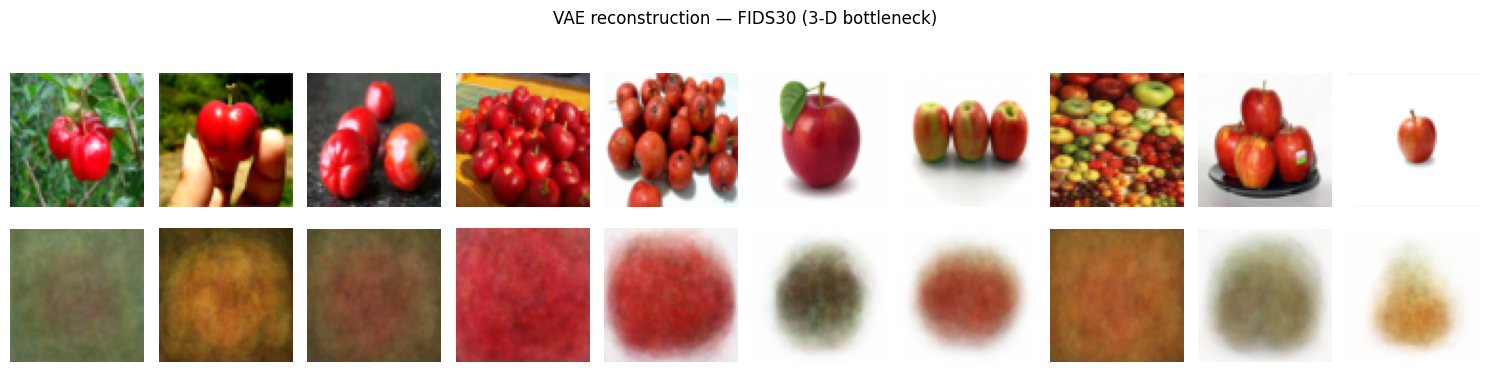

In [9]:
vae.eval()
data, labels = next(iter(test_loader))
data = data[:10].to(device)
with torch.no_grad():
    recon, _, _ = vae(data)

# reshape to (B, C, H, W) then permute to (B, H, W, C) for matplotlib
recon_imgs = recon.view(-1, 3, IMG_SIZE, IMG_SIZE).cpu().permute(0, 2, 3, 1).clamp(0, 1)
orig_imgs  = data.cpu().permute(0, 2, 3, 1)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(orig_imgs[i]);  axes[0, i].axis("off")
    axes[1, i].imshow(recon_imgs[i]); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original",     fontsize=9)
axes[1, 0].set_ylabel("Reconstructed", fontsize=9)
plt.suptitle("VAE reconstruction — FIDS30 (3-D bottleneck)", fontsize=12)
plt.tight_layout()
plt.show()

## 5. The 3D Latent Space

Encode the entire test set and plot the encoder means $\mu$ in 3D, coloured by fruit class.

In [10]:
all_mu, all_labels = [], []
vae.eval()
with torch.no_grad():
    for data, labels in test_loader:
        mu, _ = vae.encoder(data.to(device).view(-1, x_dim))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu     = torch.cat(all_mu).numpy()
all_labels = torch.cat(all_labels).numpy()

for i in range(3):
    print(f"mu_{i+1}: range [{all_mu[:, i].min():.2f}, {all_mu[:, i].max():.2f}], "
          f"mean={all_mu[:, i].mean():.2f}, std={all_mu[:, i].std():.2f}")

# save for potential latent-walk notebook
np.savez("latents_vae_3d_fids30.npz", z=all_mu, labels=all_labels)

mu_1: range [-5.72, 4.08], mean=-0.82, std=1.91
mu_2: range [-4.29, -0.08], mean=-2.32, std=0.87
mu_3: range [-3.85, 3.93], mean=0.61, std=1.41


/tmp/ipykernel_8169/1788392201.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", n_classes)


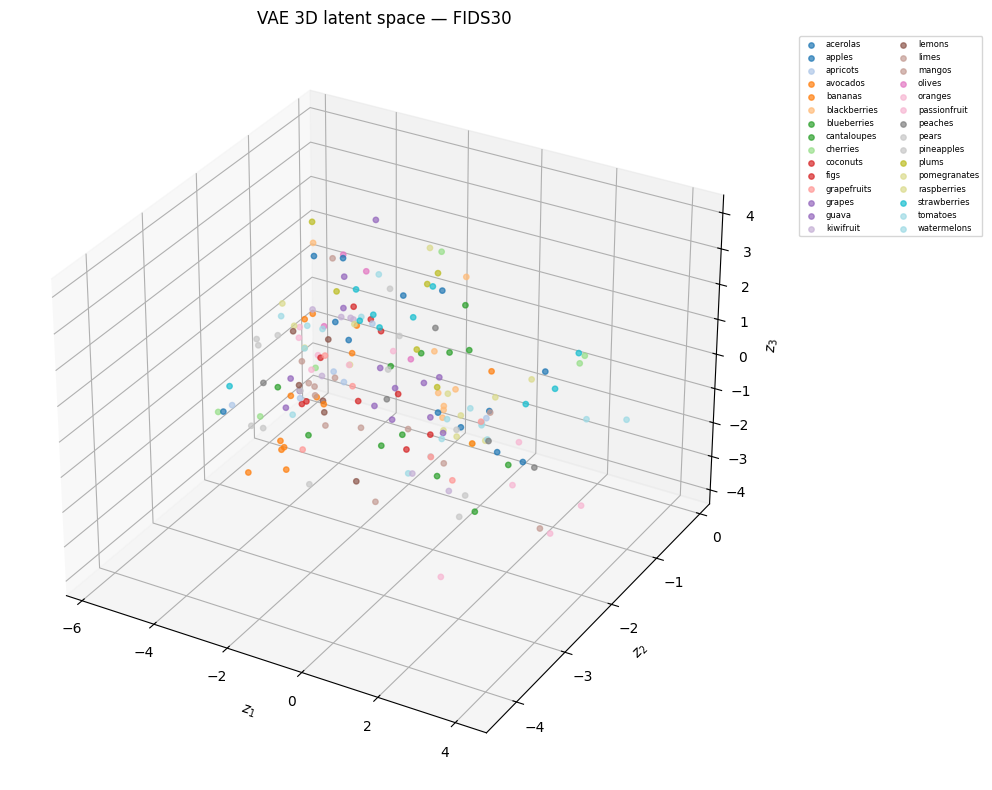

In [11]:
cmap   = plt.cm.get_cmap("tab20", n_classes)
colors = [cmap(i) for i in range(n_classes)]

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection="3d")

for cls_idx, cls_name in enumerate(class_names):
    mask = all_labels == cls_idx
    ax.scatter(all_mu[mask, 0], all_mu[mask, 1], all_mu[mask, 2],
               label=cls_name, color=colors[cls_idx], s=15, alpha=0.7)

ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$"); ax.set_zlabel("$z_3$")
ax.set_title("VAE 3D latent space — FIDS30", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

## 6. Sampling: $z \sim \mathcal{N}(0, I)$

Draw random latent vectors from the prior and decode them into fruit images.

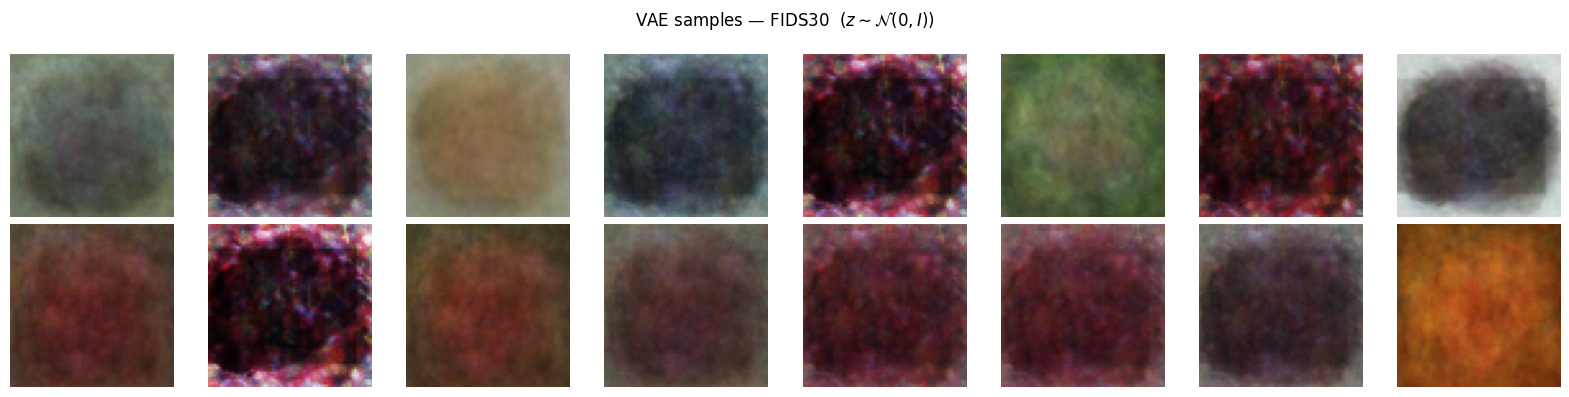

In [12]:
torch.manual_seed(0)
N = 16
z = torch.randn(N, 3, device=device)

with torch.no_grad():
    samples = vae.decoder(z).view(-1, 3, IMG_SIZE, IMG_SIZE).cpu().permute(0, 2, 3, 1).clamp(0, 1)

fig, axes = plt.subplots(2, N // 2, figsize=(N, 4))
for j, ax in enumerate(axes.flat):
    ax.imshow(samples[j])
    ax.axis("off")
plt.suptitle("VAE samples — FIDS30  ($z \\sim \\mathcal{N}(0, I)$)", fontsize=12)
plt.tight_layout()
plt.show()